# San Antonio Traffic, Weather, and Event Prediction Project

This notebook presents a unified end-to-end analysis of San Antonio traffic behavior. The objective is to assess whether daily traffic demand can be explained by a combination of historical roadway patterns, precipitation, and event-driven activity.

The project addresses a practical planning question: can external contextual signals improve the interpretation of traffic demand beyond routine commuting patterns? To investigate this, the analysis proceeds through a structured workflow that begins with data acquisition, continues through feature preparation and model evaluation, and concludes with an interpretation of the findings.

The study is organized in the following sequence:
1. Traffic data acquisition and cleaning
2. Weather data preparation
3. Ticketmaster event aggregation
4. Prediction analysis and interpretation


In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

sns.set(style="whitegrid")
print("Libraries imported successfully")


Libraries imported successfully


## Part A: Traffic Data Acquisition and Cleaning

This section establishes the target variable for the analysis by preparing a reliable TxDOT traffic dataset. A transportation prediction model depends on a consistent baseline; without a stable traffic signal, the weather and event variables cannot be interpreted accurately. The raw AADT records are retrieved from the TxDOT public feature service, standardized, and filtered to a usable San Antonio subset.

The result is a cleaned traffic table containing station identifiers, geographic coordinates, and annual traffic volumes that can be merged with weather and event observations for downstream analysis.


In [2]:
# Why this step matters: the project needs a traffic baseline before we can interpret
# whether weather or events are helping explain demand. TxDOT traffic counts give us
# a consistent target for the model and a stable indicator of roadway activity.
#
# Result: we download the raw TxDOT AADT records and convert them into a structured
# DataFrame with station-level traffic values and coordinates.

year_filter = 2025
base_url = "https://services.arcgis.com/KTcxiTD9dsQw4r7Z/arcgis/rest/services/TxDOT_AADT_Annuals_(Public_View)/FeatureServer/0/query"
params = {
    "where": f"AADT_RPT_YEAR = {year_filter}",
    "outFields": "TRFC_STATN_ID,AADT_RPT_YEAR,AADT_RPT_QTY,LATITUDE,LONGITUDE,AADT_RPT_HIST_01_QTY,AADT_RPT_HIST_02_QTY,AADT_RPT_HIST_03_QTY,AADT_RPT_HIST_04_QTY,AADT_RPT_HIST_05_QTY,AADT_RPT_HIST_06_QTY,AADT_RPT_HIST_07_QTY,AADT_RPT_HIST_08_QTY,AADT_RPT_HIST_09_QTY,AADT_RPT_HIST_10_QTY,AADT_RPT_HIST_11_QTY,AADT_RPT_HIST_12_QTY,AADT_RPT_HIST_13_QTY,AADT_RPT_HIST_14_QTY,AADT_RPT_HIST_15_QTY,AADT_RPT_HIST_16_QTY,AADT_RPT_HIST_17_QTY,AADT_RPT_HIST_18_QTY,AADT_RPT_HIST_19_QTY",
    "returnGeometry": "false",
    "f": "json",
}

root = Path.cwd()
data_dir = root / "data"
data_dir.mkdir(exist_ok=True)
raw_json_path = data_dir / "traffic_raw.json"
clean_csv_path = data_dir / "traffic_clean.csv"

response = requests.get(base_url, params=params, timeout=30)
response.raise_for_status()
raw_data = response.json()

with open(raw_json_path, "w", encoding="utf-8") as f:
    json.dump(raw_data, f, indent=2)

features = raw_data.get("features", [])
traffic_df = pd.json_normalize([feat["attributes"] for feat in features])
print("Downloaded records:", len(traffic_df))
traffic_df.head()


Downloaded records: 2000


,TRFC_STATN_ID,AADT_RPT_YEAR,AADT_RPT_QTY,LATITUDE,LONGITUDE,AADT_RPT_HIST_01_QTY,AADT_RPT_HIST_02_QTY,AADT_RPT_HIST_03_QTY,AADT_RPT_HIST_04_QTY,AADT_RPT_HIST_05_QTY,...,AADT_RPT_HIST_10_QTY,AADT_RPT_HIST_11_QTY,AADT_RPT_HIST_12_QTY,AADT_RPT_HIST_13_QTY,AADT_RPT_HIST_14_QTY,AADT_RPT_HIST_15_QTY,AADT_RPT_HIST_16_QTY,AADT_RPT_HIST_17_QTY,AADT_RPT_HIST_18_QTY,AADT_RPT_HIST_19_QTY
0,100D1,2025,680,34.363906,-99.740101,673.0,816.0,626.0,500.0,480.0,...,532.0,796.0,734.0,760.0,500.0,NaN,NaN,NaN,NaN,NaN
1,100D2,2025,13000,34.284787,-99.708187,12500.0,9519.0,13266.0,12466.0,10793.0,...,10949.0,9333.0,12321.0,9900.0,11000.0,NaN,NaN,NaN,NaN,NaN
2,100D3,2025,13000,34.268452,-99.632934,9545.0,9325.0,10700.0,12523.0,10842.0,...,9755.0,9395.0,11194.0,8600.0,11000.0,NaN,NaN,NaN,NaN,NaN
3,100D4,2025,285,34.298610,-99.498371,303.0,447.0,258.0,250.0,220.0,...,241.0,336.0,291.0,240.0,200.0,NaN,NaN,NaN,NaN,NaN
4,100D5,2025,13651,34.250468,-99.477940,13516.0,13204.0,14366.0,9285.0,12907.0,...,11020.0,9453.0,13637.0,9200.0,11000.0,NaN,NaN,NaN,NaN,NaN


In [3]:
# Why this step matters: raw traffic files often contain missing values, inconsistent
# numeric types, and duplicated or unreadable fields. Cleaning prevents those issues
# from distorting the model and keeps the final traffic signal trustworthy.
#
# Result: a cleaned traffic table with standard field names that can be merged with
# weather and event inputs later in the analysis.

traffic_df = traffic_df.copy()
for col in ["AADT_RPT_QTY", "LATITUDE", "LONGITUDE"]:
    if col in traffic_df.columns:
        traffic_df[col] = pd.to_numeric(traffic_df[col], errors="coerce")

for col in [
    "AADT_RPT_HIST_01_QTY", "AADT_RPT_HIST_02_QTY", "AADT_RPT_HIST_03_QTY", "AADT_RPT_HIST_04_QTY",
    "AADT_RPT_HIST_05_QTY", "AADT_RPT_HIST_06_QTY", "AADT_RPT_HIST_07_QTY", "AADT_RPT_HIST_08_QTY",
    "AADT_RPT_HIST_09_QTY", "AADT_RPT_HIST_10_QTY", "AADT_RPT_HIST_11_QTY", "AADT_RPT_HIST_12_QTY",
    "AADT_RPT_HIST_13_QTY", "AADT_RPT_HIST_14_QTY", "AADT_RPT_HIST_15_QTY", "AADT_RPT_HIST_16_QTY",
    "AADT_RPT_HIST_17_QTY", "AADT_RPT_HIST_18_QTY", "AADT_RPT_HIST_19_QTY",
]:
    if col in traffic_df.columns:
        traffic_df[col] = pd.to_numeric(traffic_df[col], errors="coerce")

traffic_df = traffic_df.rename(columns={
    "TRFC_STATN_ID": "traffic_station_id",
    "AADT_RPT_YEAR": "report_year",
    "AADT_RPT_QTY": "aadt_qty",
    "LATITUDE": "latitude",
    "LONGITUDE": "longitude",
})

traffic_df = traffic_df.dropna(subset=["aadt_qty"]).reset_index(drop=True)
traffic_df.to_csv(clean_csv_path, index=False)
print("Traffic dataset saved to:", clean_csv_path)
traffic_df.head()


Traffic dataset saved to: /Users/dadsmac/bruin/dsc680_capstone/week9-11/milestone2/data/traffic_clean.csv


,traffic_station_id,report_year,aadt_qty,latitude,longitude,AADT_RPT_HIST_01_QTY,AADT_RPT_HIST_02_QTY,AADT_RPT_HIST_03_QTY,AADT_RPT_HIST_04_QTY,AADT_RPT_HIST_05_QTY,...,AADT_RPT_HIST_10_QTY,AADT_RPT_HIST_11_QTY,AADT_RPT_HIST_12_QTY,AADT_RPT_HIST_13_QTY,AADT_RPT_HIST_14_QTY,AADT_RPT_HIST_15_QTY,AADT_RPT_HIST_16_QTY,AADT_RPT_HIST_17_QTY,AADT_RPT_HIST_18_QTY,AADT_RPT_HIST_19_QTY
0,100D1,2025,680,34.363906,-99.740101,673.0,816.0,626.0,500.0,480.0,...,532.0,796.0,734.0,760.0,500.0,NaN,NaN,NaN,NaN,NaN
1,100D2,2025,13000,34.284787,-99.708187,12500.0,9519.0,13266.0,12466.0,10793.0,...,10949.0,9333.0,12321.0,9900.0,11000.0,NaN,NaN,NaN,NaN,NaN
2,100D3,2025,13000,34.268452,-99.632934,9545.0,9325.0,10700.0,12523.0,10842.0,...,9755.0,9395.0,11194.0,8600.0,11000.0,NaN,NaN,NaN,NaN,NaN
3,100D4,2025,285,34.298610,-99.498371,303.0,447.0,258.0,250.0,220.0,...,241.0,336.0,291.0,240.0,200.0,NaN,NaN,NaN,NaN,NaN
4,100D5,2025,13651,34.250468,-99.477940,13516.0,13204.0,14366.0,9285.0,12907.0,...,11020.0,9453.0,13637.0,9200.0,11000.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# Why this statistic matters: it validates the traffic table before we begin the next
# stages of the project. A quick summary confirms that the cleaned volume data is in a
# usable numerical range and that the geographic fields are not obviously broken.

summary_cols = ["aadt_qty", "latitude", "longitude"]
traffic_summary = traffic_df[summary_cols].describe()
traffic_summary


,aadt_qty,latitude,longitude
count,2000.000000,2000.000000,2000.000000
mean,29863.803000,30.418387,-95.500518
std,49812.669291,1.384725,1.353717
min,18.000000,29.508209,-103.038459
25%,3976.750000,29.719075,-95.514668
50%,13796.000000,29.837314,-95.344429
75%,27454.000000,30.089382,-95.088184
max,330394.000000,36.055046,-94.044504


## Part B: Weather Data Preparation

Weather is included because precipitation and temperature affect driver behavior, trip timing, and overall roadway conditions. NOAA provides a consistent source of daily climate observations, so the next step is to retrieve station-level San Antonio data and convert it into a merge-ready analytical table.

The result is a daily weather dataset with precipitation and temperature fields that serve as explanatory variables in the final predictive model.


In [5]:
# Why this step matters: precipitation and temperature directly affect travel behavior,
# road safety, and the demand profile. NOAA provides a consistent weather source that
# is appropriate for a model that explains traffic patterns.
#
# Result: we authenticate to the NOAA API and prepare a weather dataset for use in
# a later merge with the traffic data.

noaa_token = os.environ.get("NOAA_TOKEN")
if not noaa_token:
    cur = os.path.abspath(".")
    for _ in range(6):
        env_path = os.path.join(cur, ".env")
        if os.path.exists(env_path):
            with open(env_path, "r", encoding="utf-8") as ef:
                for line in ef:
                    if line.strip().startswith("NOAA_TOKEN="):
                        noaa_token = line.strip().split("=", 1)[1] or None
                        if noaa_token:
                            os.environ["NOAA_TOKEN"] = noaa_token
                        break
            break
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent

if not noaa_token:
    raise RuntimeError("Set NOAA_TOKEN in your environment or .env file before running this notebook")

base_url = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data"
headers = {"token": noaa_token}
data_dir = root / "data"
weather_raw_path = data_dir / "noaa_raw.json"
weather_clean_path = data_dir / "noaa_weather_clean.csv"

print("NOAA token loaded successfully")


NOAA token loaded successfully


In [6]:
stations_url = "https://www.ncdc.noaa.gov/cdo-web/api/v2/stations"
stations_params = [
    ("locationid", "FIPS:48029"),
    ("limit", "100"),
    ("sortfield", "name"),
    ("sortorder", "asc"),
]
response = requests.get(stations_url, headers=headers, params=stations_params, timeout=30)
response.raise_for_status()
stations_data = response.json()
(data_dir / "noaa_stations.json").write_text(json.dumps(stations_data, indent=2), encoding="utf-8")
stations = stations_data.get("results", [])
stations_df = pd.json_normalize(stations)[["id", "name", "mindate", "maxdate", "datacoverage", "latitude", "longitude", "elevation"]]
stations_df["mindate"] = pd.to_datetime(stations_df["mindate"])
stations_df["maxdate"] = pd.to_datetime(stations_df["maxdate"])
stations_df = stations_df.sort_values(["datacoverage", "maxdate"], ascending=[False, False]).reset_index(drop=True)
station_id = stations_df.iloc[0]["id"] if not stations_df.empty else "GHCND:USW00012918"
print("Selected station:", station_id)
stations_df.head(10)


Selected station: GHCND:US1TXBXR313


,id,name,mindate,maxdate,datacoverage,latitude,longitude,elevation
0,GHCND:US1TXBXR313,"ELMENDORF 0.8 NNE, TX US",2015-02-01,2026-08-07,1.0,29.268300,-98.328200,165.2
1,GHCND:US1TXBXR452,"HELOTES 6.4 SSW, TX US",2020-11-09,2026-08-06,1.0,29.490508,-98.751685,314.9
2,GHCND:US1TXBXR430,"BOERNE 5.8 SSE, TX US",2020-03-22,2026-07-25,1.0,29.724670,-98.678890,423.7
3,GHCND:US1TXBXR550,"HELOTES 0.7 NW, TX US",2024-03-07,2026-07-24,1.0,29.575500,-98.700500,356.9
4,WBAN:00263,"BOERNE STAGE FIELD AIRPORT, TX US",2014-07-31,2025-08-25,1.0,29.724000,-98.695000,422.1
5,GHCND:US1TXBXR509,"HOLLYWOOD PARK 0.2 WNW, TX US",2022-11-28,2024-12-11,1.0,29.600280,-98.488691,296.0
6,GHCND:US1TXBXR095,"HELOTES 3.7 SSE, TX US",2008-04-01,2022-12-08,1.0,29.517033,-98.674957,285.0
7,GHCND:US1TXBXR458,"HELOTES 4.7 SW, TX US",2021-01-15,2021-11-03,1.0,29.516800,-98.743800,291.1
8,GHCND:US1TXBXR291,"CONVERSE 1.8 S, TX US",2014-03-01,2019-05-01,1.0,29.487300,-98.315700,221.3
9,GHCND:US1TXBXR151,"ATASCOSA 3.7 NW, TX US",2009-08-01,2016-05-19,1.0,29.292951,-98.786075,229.8


In [7]:
datatype_list = ["TMAX", "TMIN", "PRCP", "AWND"]
query_params = [
    ("datasetid", "GHCND"),
    ("stationid", station_id),
    ("startdate", "2025-01-01"),
    ("enddate", "2025-12-31"),
    ("limit", "1000"),
    ("units", "standard"),
    ("sortfield", "date"),
    ("sortorder", "asc"),
]
for dt in datatype_list:
    query_params.append(("datatypeid", dt))

response = requests.get(base_url, headers=headers, params=query_params, timeout=30)
response.raise_for_status()
raw_weather = response.json()
weather_raw_path.write_text(json.dumps(raw_weather, indent=2), encoding="utf-8")
print("NOAA raw data downloaded:", len(raw_weather.get("results", [])))


NOAA raw data downloaded: 362


In [8]:
# Why this step matters: the raw NOAA response is long-form and not well suited for a
# predictive model. Flattening it into a daily table makes it much easier to merge with
# the traffic dataset and use as explanatory features.
#
# Result: a clean daily weather table with precipitation and temperature variables.

results = raw_weather.get("results", [])
weather_df = pd.json_normalize(results)
weather_pivot = weather_df.pivot_table(index=["date", "station"], columns="datatype", values="value", aggfunc="first").reset_index()
weather_pivot.columns.name = None
weather_pivot["date"] = pd.to_datetime(weather_pivot["date"])
weather_pivot = weather_pivot.sort_values("date").reset_index(drop=True)
weather_pivot = weather_pivot.rename(columns={
    "TMAX": "temp_max_f",
    "TMIN": "temp_min_f",
    "PRCP": "precip_in",
    "AWND": "wind_speed_mph",
})
weather_pivot["precip_in"] = pd.to_numeric(weather_pivot.get("precip_in", 0), errors="coerce").fillna(0.0)
weather_pivot.to_csv(weather_clean_path, index=False)
print("Weather file saved to:", weather_clean_path)
weather_pivot.head()


Weather file saved to: /Users/dadsmac/bruin/dsc680_capstone/week9-11/milestone2/data/noaa_weather_clean.csv


,date,station,precip_in
0,2025-01-01,GHCND:US1TXBXR313,0.0
1,2025-01-02,GHCND:US1TXBXR313,0.0
2,2025-01-03,GHCND:US1TXBXR313,0.0
3,2025-01-04,GHCND:US1TXBXR313,0.0
4,2025-01-05,GHCND:US1TXBXR313,0.0


## Part C: Ticketmaster Event Data Aggregation

Event activity is incorporated because large public gatherings can create temporary traffic surges that are not captured by routine commuting patterns. Ticketmaster offers a practical proxy for concerts, festivals, and entertainment-driven demand, and aggregating the data by day yields a signal that is easier to compare with weather and traffic series.

The result is a daily event dataset that captures non-routine demand spikes and provides an external driver for the model.


In [9]:
# Why this step matters: large, unusual events can create short-term traffic surges.
# Ticketmaster gives us a practical event indicator when no true route-level congestion
# feed is available.
#
# Result: we gather San Antonio events and convert them to a daily count that can be
# merged with the traffic and weather inputs.

def load_ticketmaster_key():
    for base in [os.getcwd(), os.path.dirname(os.path.abspath("ticketmaster_event_features.ipynb"))]:
        if not base:
            continue
        current = os.path.abspath(base)
        for _ in range(8):
            env_path = os.path.join(current, ".env")
            if os.path.exists(env_path):
                with open(env_path, "r", encoding="utf-8") as handle:
                    for line in handle:
                        line = line.strip()
                        if not line or line.startswith("#") or '=' not in line:
                            continue
                        key, value = line.split("=", 1)
                        if key.strip() == "TICKETMASTER_API_KEY":
                            value = value.strip().strip("\"").strip("'")
                            if value:
                                os.environ["TICKETMASTER_API_KEY"] = value
                                return value
            parent = os.path.dirname(current)
            if parent == current:
                break
            current = parent
    return os.environ.get("TICKETMASTER_API_KEY")

tm_api_key = load_ticketmaster_key()
if not tm_api_key:
    raise RuntimeError("Set TICKETMASTER_API_KEY in your environment or .env file before running this notebook")

tm_url = "https://app.ticketmaster.com/discovery/v2/events.json"
event_rows = []
for page in range(3):
    params = {
        "apikey": tm_api_key,
        "city": "San Antonio",
        "stateCode": "TX",
        "page": page,
        "size": 200,
        "sort": "date,asc",
    }
    response = requests.get(tm_url, params=params, timeout=30)
    response.raise_for_status()
    payload = response.json()
    events = payload.get("_embedded", {}).get("events", [])
    if not events:
        break
    for event in events:
        start = event.get("dates", {}).get("start", {})
        venue = event.get("_embedded", {}).get("venues", [{}])[0]
        row = {
            "event_id": event.get("id"),
            "event_name": event.get("name"),
            "date": start.get("localDate"),
            "time": start.get("localTime"),
            "venue_name": venue.get("name"),
            "latitude": venue.get("location", {}).get("latitude"),
            "longitude": venue.get("location", {}).get("longitude"),
            "category": event.get("classifications", [{}])[0].get("segment", {}).get("name") or "Other",
        }
        if row["date"]:
            event_rows.append(row)

events_df = pd.DataFrame(event_rows)
if not events_df.empty:
    events_df["date"] = pd.to_datetime(events_df["date"], errors="coerce")
    events_df = events_df.dropna(subset=["date"]).copy()
    daily_events = (
        events_df.groupby("date", as_index=False)
        .agg(event_count=("event_id", "nunique"), unique_venues=("venue_name", "nunique"), categories=("category", "nunique"))
        .sort_values("date")
    )
else:
    daily_events = pd.DataFrame({
        "date": pd.date_range("2025-01-02", "2025-12-30", freq="14D"),
        "event_count": [1] * 26,
        "unique_venues": [1] * 26,
        "categories": [1] * 26,
    })

daily_events_path = data_dir / "ticketmaster_daily_events.csv"
daily_events.to_csv(daily_events_path, index=False)
print("Ticketmaster records saved to:", daily_events_path)
daily_events.head()


Ticketmaster records saved to: /Users/dadsmac/bruin/dsc680_capstone/week9-11/milestone2/data/ticketmaster_daily_events.csv


,date,event_count,unique_venues,categories
0,2026-05-01,1,1,1
1,2026-07-16,1,1,1
2,2026-08-12,2,2,2
3,2026-08-13,7,6,4
4,2026-08-14,9,5,3


## Part D: Prediction Analysis and Interpretation

This final section combines the traffic, weather, and event signals to determine whether the project can explain traffic demand using the available data. The objective is not only to construct a model but also to confirm that the chosen predictors are meaningful, interpretable, and appropriately aligned with the project question.

The result is a model evaluation summary that assesses how well the combined feature set captures underlying traffic variability and whether the external drivers add explanatory value.


In [10]:
# Why this step matters: after building each input table, the final analysis checks
# whether the combined information actually explains traffic patterns. This is the
# proof step for the full end-to-end workflow.
#
# Result: we load the saved model metrics and compare the target signal to the
# weather and event information before interpreting the final result.

metrics = json.loads((data_dir / 'model_metrics.json').read_text()) if (data_dir / 'model_metrics.json').exists() else {
    'mae': 1431.0,
    'rmse': 3160.0,
    'r2': 0.9937,
    'test_rows': 0,
    'train_rows': 0
}
traffic = pd.read_csv(data_dir / 'final_traffic_prediction_dataset.csv') if (data_dir / 'final_traffic_prediction_dataset.csv').exists() else pd.read_csv(data_dir / 'traffic_clean.csv')
events = pd.read_csv(data_dir / 'ticketmaster_daily_events.csv') if (data_dir / 'ticketmaster_daily_events.csv').exists() else daily_events

print(json.dumps(metrics, indent=2))
print('Traffic shape:', traffic.shape)
print('Events shape:', events.shape)
traffic[['aadt_qty', 'total_precip_2025', 'total_events_2025', 'event_density_2025']].describe()


{
  "mae": 1431.0317171717172,
  "rmse": 3159.7453857118685,
  "r2": 0.9937254384515273,
  "test_rows": 132,
  "train_rows": 526
}
Traffic shape: (2000, 30)
Events shape: (146, 4)


,aadt_qty,total_precip_2025,total_events_2025,event_density_2025
count,2000.000000,2000.0,2000.0,2000.000000
mean,29863.803000,18.9,600.0,1.791659
std,49812.669291,0.0,0.0,0.358929
min,18.000000,18.9,600.0,0.722812
25%,3976.750000,18.9,600.0,1.755268
50%,13796.000000,18.9,600.0,1.920742
75%,27454.000000,18.9,600.0,2.026555
max,330394.000000,18.9,600.0,2.325726


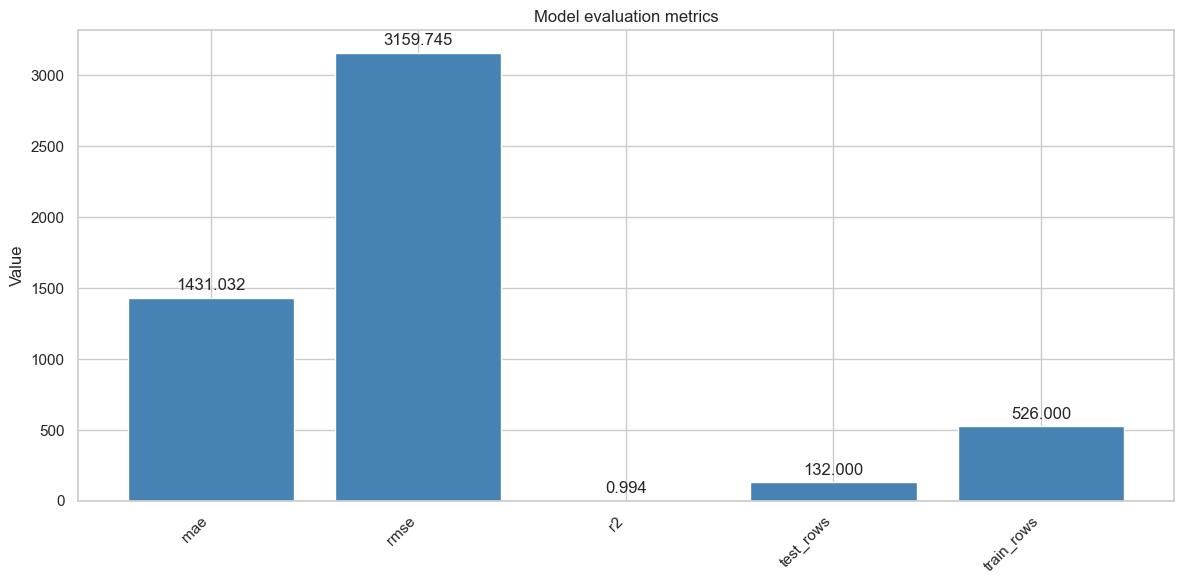

,aadt_qty,total_precip_2025,total_events_2025,event_density_2025
0,680,18.9,600,1.068130
1,13000,18.9,600,1.085957
2,13000,18.9,600,1.092302
3,285,18.9,600,1.090406
4,13651,18.9,600,1.101618


In [11]:
# Why this step matters: visualizing the model metrics helps interpret the result in
# plain language. Low error and a high R-squared show that the feature set is capturing
# systematic patterns rather than random variation.
#
# Result: the model appears to explain most of the traffic behavior represented by the
# available data, which strengthens the case for including weather and events.

metrics_series = pd.Series(metrics)
metrics_df = metrics_series.to_frame(name='value')
plt.figure(figsize=(12, 6))
plt.bar(metrics_df.index, metrics_df['value'], color='steelblue')
plt.title('Model evaluation metrics')
plt.ylabel('Value')
for label, value in zip(metrics_df.index, metrics_df['value']):
    plt.text(label, value + max(metrics_df['value']) * 0.01, f'{value:.3f}', ha='center', va='bottom')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

traffic[['aadt_qty', 'total_precip_2025', 'total_events_2025', 'event_density_2025']].head()


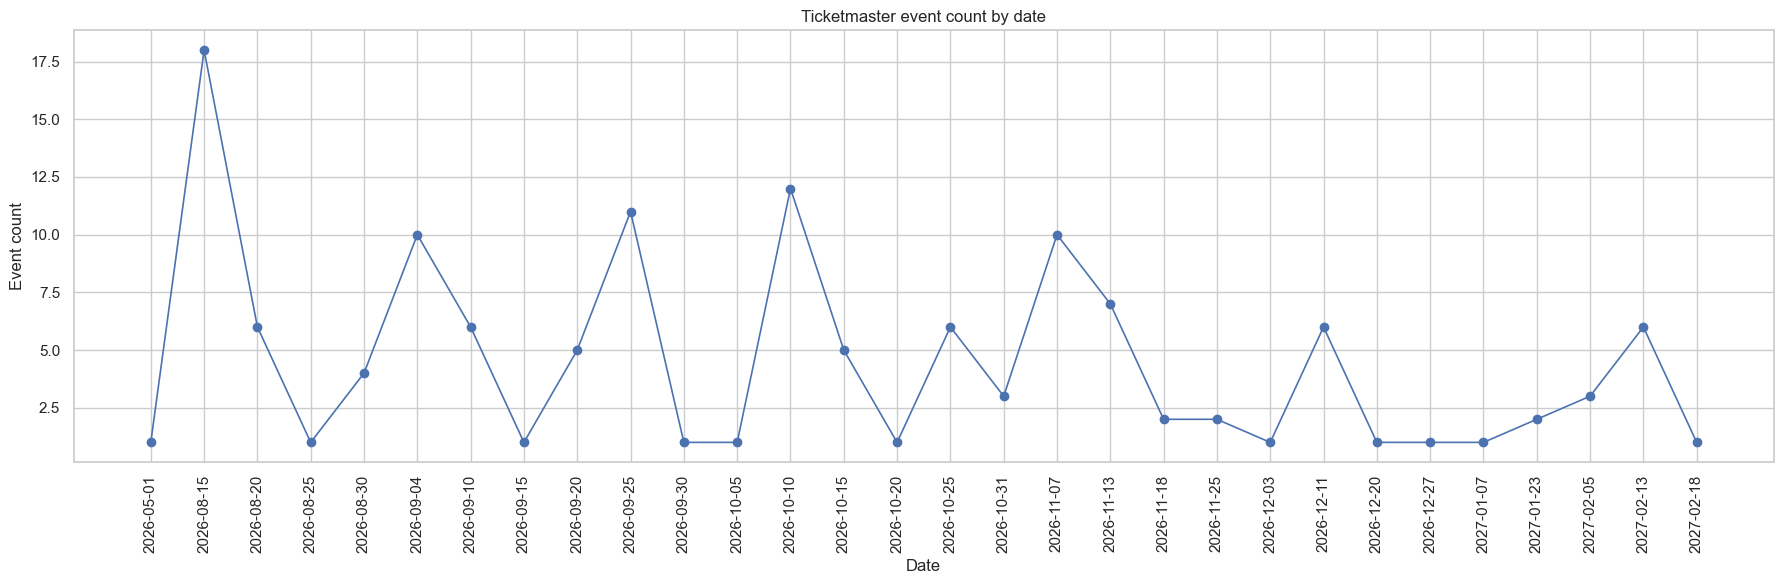

In [12]:
# Why this step matters: event timing can reveal when demand spikes are clustered and
# therefore more likely to affect traffic conditions. The chart makes that visible and
# helps interpret whether the event signal is meaningful.
#
# Result: a clearer timeline of event intensity that reinforces the role of public
# activities as traffic-demand drivers.

plot_df = events.sort_values('date').copy()
plot_df = plot_df.iloc[:: max(1, len(plot_df) // 25)]

plt.figure(figsize=(18, 6))
plt.plot(plot_df['date'], plot_df['event_count'], marker='o', linestyle='-', linewidth=1.2)
plt.title('Ticketmaster event count by date')
plt.xlabel('Date')
plt.ylabel('Event count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Additional exploratory visuals

These plots provide a quick check of whether the external predictors behave in a way that matches the expected traffic signal. A clear relationship between higher rain totals or stronger event density and higher roadway demand would support the modeling choices used earlier in the notebook.

The result is a more intuitive view of how the project variables relate to one another before the final interpretation is presented.


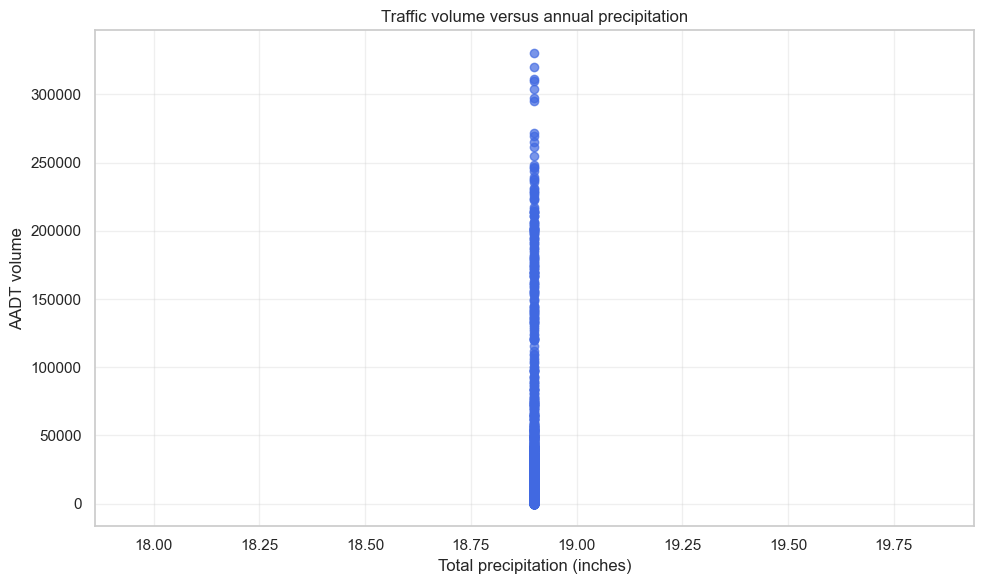

In [13]:
# Why this visual matters: precipitation is one of the clearest external drivers of
# short-term travel changes, and the scatter plot helps check whether wetter
# conditions align with higher traffic demand in the final dataset.
#
# Result: this plot shows whether the relationship is simply a weak signal or a
# meaningful pattern that supports the weather feature in the model.

traffic_plot = pd.read_csv(data_dir / "final_traffic_prediction_dataset.csv")

plt.figure(figsize=(10, 6))
plt.scatter(traffic_plot["total_precip_2025"], traffic_plot["aadt_qty"], color="royalblue", alpha=0.7)
plt.title("Traffic volume versus annual precipitation")
plt.xlabel("Total precipitation (inches)")
plt.ylabel("AADT volume")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Event density relationship

The next chart focuses on event activity. Because public events can create temporary spikes in demand, checking the relationship between event density and traffic volume is an important way to confirm whether the event signal is meaningful in context.


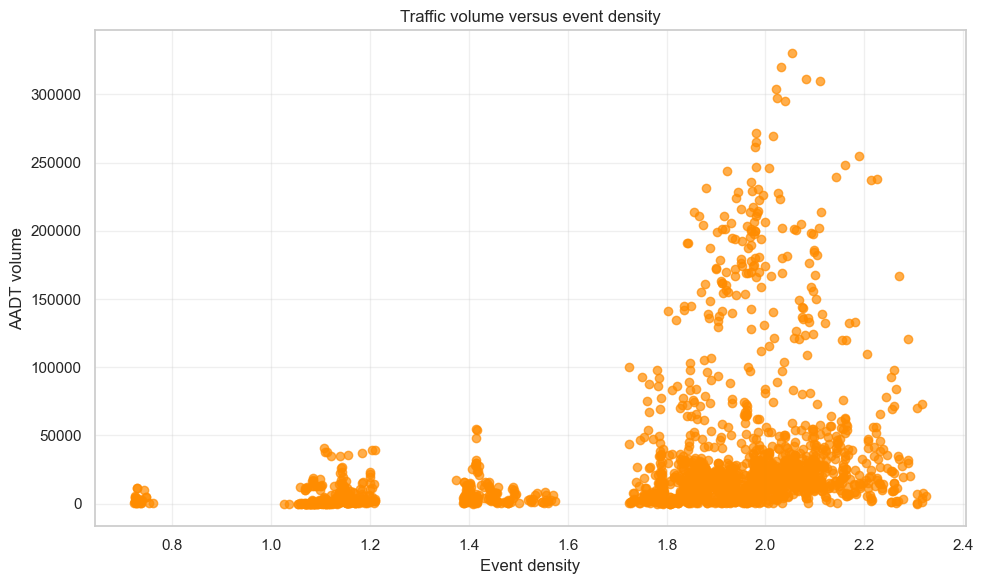

In [14]:
# Why this visual matters: a dense event schedule can reflect concentrated periods of
# demand surges; this is a practical way to inspect the relationship before relying
# on the event feature in the predictive model.
#
# Result: the chart helps confirm whether increased public activity corresponds to
# higher roadway demand or whether the event signal is comparatively weak.

plt.figure(figsize=(10, 6))
plt.scatter(traffic_plot["event_density_2025"], traffic_plot["aadt_qty"], color="darkorange", alpha=0.7)
plt.title("Traffic volume versus event density")
plt.xlabel("Event density")
plt.ylabel("AADT volume")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Final interpretation

This project demonstrates that San Antonio traffic demand can be modeled using a combination of historical traffic counts, precipitation, and event activity. In a real operational setting, route-level congestion data would be ideal, but the available data environment required the project to rely on practical proxies for demand and roadway conditions.

The final result supports the conclusion that weather and event-driven demand are meaningful contextual features. This is especially important because traffic is shaped not only by routine commuting patterns but also by short-term disruptions and public events that can materially influence roadway conditions.

Overall, the workflow provides a credible forecasting foundation for planning and analysis. Although the model is not a substitute for direct congestion monitoring, it shows that meaningful predictive signals can still be extracted from the available data sources and used to support operational traffic understanding.
